## This notebook has the goal of providing a clear motivation for using a Mixture of Factor Analyzers over a PCA model

It will implement the following tests:
1. The Reconstruction vs. Compression Trade-off (The Math Test)
2. The Spectral Library Match (The Physics Test)
3. The Latent Factor Interpretability (The Science Test)
4. The Outlier Rejection Threshold (The Streaming Prerequisite)


In [1]:
import torch
import glob
import matplotlib.pyplot as plt
from mfa import MFA
from utils import get_data, reconstruct_mfa, calculate_rmse, calculate_sam, DataProduct
from hypso import Hypso
import numpy as np
import matplotlib.pyplot as plt

These are the setup variables for the model:

In [2]:
data_product = DataProduct.L1B
Test_PCA_on_L2Normalized = False
Test_MFA_on_L2Normalized = True


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_data_dir = glob.glob(f'../data/testing_{data_product.value}/*.nc')
print(f"Found {len(test_data_dir)} files.")

Found 16 files.


## Model testing

Model testing consists of 3 main tests

1. **Reconstruction:** The RMSE and SAM is calculated for reconstruction from latent space for both the MFA and the result is compared to the PCA-model

2. **Clasification:** An visual classification test is performed. In this test a colour is given to each factor, and for a given image, each pixel is assinged a Factor. A visual test is performed to see if the creared clusters represents physical materials.

3. **Loadings:** For each loading, *mu* is plotted. The object is to see how *mu* differs for each Factor. If for the factors *mu* has the same shape but diffrent intensity, that is evidense for the model only capturing differnet light intensities and clustering based on those. if *mu* has different shapes, it is evident that the model has learn usefull spectra. Preferably, *mu* should resemble the spectra of vegetation, ocean, cloud, etc.  

In [3]:
target_total_samples = 25000

test_data_list = get_data(test_data_dir, data_product, target_total_samples)

test_data = torch.from_numpy(test_data_list).float().to(device)

Aiming to extract ~1562 pixels per file from 16 files to reach a total of ~25000 samples.
1/16 | File: ../data/testing_l1b\aregantsea2_2025-03-11T08-12-43Z-l1b.nc | Extracted 1562 pixels.
2/16 | File: ../data/testing_l1b\a_magdalen_2022-07-17T14-37-29Z-l1b.nc | Extracted 1562 pixels.
3/16 | File: ../data/testing_l1b\a_mwanza_2022-07-21T07-43-03Z-l1b.nc | Extracted 1562 pixels.
4/16 | File: ../data/testing_l1b\a_plocan_2025-01-11T11-23-41Z-l1b.nc | Extracted 1562 pixels.
5/16 | File: ../data/testing_l1b\caspiansea2_2024-07-07T06-58-07Z-l1b.nc | Extracted 1562 pixels.
6/16 | File: ../data/testing_l1b\gobabeb_2024-03-14T09-14-22Z-l1b.nc | Extracted 1562 pixels.
7/16 | File: ../data/testing_l1b\jiaozhouBayBridge_2022-11-20T01-55-00Z-l1b.nc | Extracted 1562 pixels.
8/16 | File: ../data/testing_l1b\lacrau_2025-01-17T09-40-10Z-l1b.nc | Extracted 1562 pixels.
9/16 | File: ../data/testing_l1b\lakevolta_2023-01-19T09-40-06Z-l1b.nc | Extracted 1562 pixels.
10/16 | File: ../data/testing_l1b\prince

## Fetching the models

In [4]:
try: 
    pca_state = torch.load("models/pca.pt", map_location=device)
except:
    print("There was an error loading the PCA-model")
try:
    mfa_state = torch.load("models/mfa.pt", map_location=device)
    K = mfa_state['hyperparameters']['n_components']
    q = mfa_state['hyperparameters']['n_factors']
    n_features = mfa_state['hyperparameters']['n_features']
    # Initialize Model
    mfa_model = MFA(n_components=K, n_channels=n_features, n_factors=q, device=device)
    mfa_model.load_state_dict(mfa_state['model_state_dict'])
    mfa_model.eval()

except:
    print("There was an error loading the MFA-model")
try: 
    otfp_mfa_state = torch.load("models/otfp_mfa.pt", map_location=device)
    K = otfp_mfa_state['hyperparameters']['n_components']
    q = otfp_mfa_state['hyperparameters']['n_factors']
    n_features = otfp_mfa_state['hyperparameters']['n_features']
    # Initialize Model
    otfp_mfa_model = MFA(n_components=K, n_channels=n_features, n_factors=q, device=device)
    otfp_mfa_model.load_state_dict(otfp_mfa_state['model_state_dict'])
    otfp_mfa_model.eval()
except:
    print("There was an error loading the OTFP-MFA model")

In [5]:
def print_mfa_summary(mfa_model):
    """
    Prints a formatted dashboard of the pure PyTorch MFA model state.
    Assumes mfa_model is an instance of the MFA (nn.Module) class.
    """
    print("="*55)
    print(" MFA SYSTEM STATE")
    print("="*55)
    
    # Model Architecture
    print(f"\n[MFA ARCHITECTURE]")
    print(f"Channels (D)                : {mfa_model.D}")
    print(f"Latent Factors (q)          : {mfa_model.q}")
    print(f"Total Components (K)        : {mfa_model.K}")
    
    print(f"\n[COMPONENT BREAKDOWN]")
    print("-" * 55)
    
    # Convert tensors to CPU numpy arrays for easy string formatting
    pi_weights = torch.exp(mfa_model.log_pi).detach().cpu().numpy()
    s0_mass = mfa_model.S0.detach().cpu().numpy()
    updates = mfa_model.update_counts.detach().cpu().numpy()
    
    for k in range(mfa_model.K):
        print(f"  ▶ Component {k}:")
        print(f"    ├─ Mixing Weight (π)       : {pi_weights[k]:.2%}")
        print(f"    ├─ Effective Pixel Mass    : {s0_mass[k]:,.1f} (from S0)")
        print(f"    └─ Stepwise EM Updates     : {int(updates[k])}\n")
        
    print("="*55)

# Call it directly on your loaded PyTorch model
print_mfa_summary(otfp_mfa_model)

 MFA SYSTEM STATE

[MFA ARCHITECTURE]
Channels (D)                : 120
Latent Factors (q)          : 8
Total Components (K)        : 16

[COMPONENT BREAKDOWN]
-------------------------------------------------------
  ▶ Component 0:
    ├─ Mixing Weight (π)       : 14.49%
    ├─ Effective Pixel Mass    : 0.4 (from S0)
    └─ Stepwise EM Updates     : 1087

  ▶ Component 1:
    ├─ Mixing Weight (π)       : 9.60%
    ├─ Effective Pixel Mass    : 0.3 (from S0)
    └─ Stepwise EM Updates     : 98

  ▶ Component 2:
    ├─ Mixing Weight (π)       : 7.53%
    ├─ Effective Pixel Mass    : 0.2 (from S0)
    └─ Stepwise EM Updates     : 673

  ▶ Component 3:
    ├─ Mixing Weight (π)       : 13.93%
    ├─ Effective Pixel Mass    : 0.4 (from S0)
    └─ Stepwise EM Updates     : 1300

  ▶ Component 4:
    ├─ Mixing Weight (π)       : 0.09%
    ├─ Effective Pixel Mass    : 0.0 (from S0)
    └─ Stepwise EM Updates     : 98

  ▶ Component 5:
    ├─ Mixing Weight (π)       : 8.48%
    ├─ Effective Pixe

### Calculating the RMSE and SAM reconstruction

In [6]:
with torch.no_grad():
    # Flatten Data to 2D
    X_raw = test_data.clone().detach().to(dtype=torch.float32, device=device)
    # Reshape only if it is 3D
    if X_raw.ndim == 3:
        X_raw = X_raw.reshape(-1, X_raw.shape[-1])

    #  PCA Reconstruction
    pca_components = pca_state['components'].to(device)
    pca_mean = pca_state['mean'].to(device)
    X_test_PCA = X_raw - pca_mean 
    # Encode
    z_pca = torch.matmul(X_test_PCA, pca_components)
    # Decode
    X_rec_pca_centered = torch.matmul(z_pca, pca_components.T)
    # De-process (Add mean)
    X_rec_pca_final = X_rec_pca_centered + pca_mean

    rmse_pca = calculate_rmse(X_raw, X_rec_pca_final)
    sam_pca = calculate_sam(X_raw, X_rec_pca_final)

    print("=== PCA Reconstruction Benchmark ===")
    print(f"PCA (q={pca_state['n_components_995']}, RMSE = {rmse_pca:.4f}, SAM = {sam_pca:.4f}")

    X_for_reconstruction = X_raw
    if Test_MFA_on_L2Normalized:
        print("Applying L2 Normalization to data")
        norms = torch.norm(X_raw, p=2, dim=1, keepdim=True)
        epsilon = 1e-8
        X_for_reconstruction = X_raw / (norms + epsilon)
    
    X = X_for_reconstruction
    # MFA Benchmarks
    X_rec_mfa_shape, mfa_cluster_ids = reconstruct_mfa(mfa_model, X)
    X_rec_otfp_mfa_shape, otfp_mfa_cluster_ids = reconstruct_mfa(otfp_mfa_model, X)
    
    pixel_norms = 1

    if Test_MFA_on_L2Normalized:
        pixel_norms = torch.linalg.norm(X_raw, dim=1, keepdim=True).clamp(min=1e-8)
    
    X_rec_mfa_physical = X_rec_mfa_shape * pixel_norms # Restore magnitude
    X_rec_otfp_mfa_physical = X_rec_otfp_mfa_shape * pixel_norms
    
    rmse_mfa = calculate_rmse(X_raw, X_rec_mfa_physical)
    sam_mfa = calculate_sam(X_raw, X_rec_mfa_physical)

    rmse_otfp_mfa = calculate_rmse(X_raw, X_rec_otfp_mfa_physical)
    sam_otfp_mfa = calculate_sam(X_raw, X_rec_otfp_mfa_physical)

    print("=== MFA Reconstruction Benchmark ===")
    print(f"MFA (K={mfa_model.K}, q={mfa_model.q}, RMSE = {rmse_mfa:.4f}, SAM = {sam_mfa:.4f})")
    # Clear variables to free memory for PCA benchmark

    print("=== OTFP-MFA Reconstruction Benchmark ===")
    print(f"MFA (K={otfp_mfa_model.K}, q={otfp_mfa_model.q}, RMSE = {rmse_otfp_mfa:.4f}, SAM = {sam_otfp_mfa:.4f})")

    del X_raw, X, X_for_reconstruction, X_rec_mfa_shape, X_rec_otfp_mfa_shape, X_rec_mfa_physical, X_rec_otfp_mfa_physical, X_test_PCA, X_rec_pca_final, z_pca, test_data, X_rec_pca_centered


=== PCA Reconstruction Benchmark ===
PCA (q=5, RMSE = 2.6219, SAM = 0.0485
Applying L2 Normalization to data
=== MFA Reconstruction Benchmark ===
MFA (K=7, q=4, RMSE = 2.1857, SAM = 0.0373)
=== OTFP-MFA Reconstruction Benchmark ===
MFA (K=16, q=8, RMSE = 1.9604, SAM = 0.0326)


### Debugging the component-rotation

In [ ]:
NUM_TEST_FILES = 6
num_test_files = min(NUM_TEST_FILES, len(test_data_dir))
print(f"Using {num_test_files} files for testing.")

# Create the figure grid: h rows (images), w columns (1 RGB + num_models)
h = num_test_files
w = 3

# Scale figure size dynamically based on the grid width/height
fig, axes = plt.subplots(h, w, figsize=(w * 6, h * 5))

# Ensure axes is a 2D array even if h=1 or w=1
if h == 1:
    axes = np.expand_dims(axes, axis=0)
if w == 1:
    axes = np.expand_dims(axes, axis=1)

# 2. Pre-load all models to avoid constantly reloading them inside the image loop
model_states = [mfa_state, otfp_mfa_state]
loaded_models = []
for state in model_states:
    
    # Extract params
    K = state['hyperparameters']['n_components']
    q = state['hyperparameters']['n_factors']
    n_features = state['hyperparameters']['n_features']
    
    # Initialize Model
    mfa_model = MFA(n_components=K, n_channels=n_features, n_factors=q, device=device)
    mfa_model.load_state_dict(state['model_state_dict'])
    mfa_model.eval()
    
    # Deduce the preprocessing method from filename string (safest approach)
    model_type = "MFA"
    if state is otfp_mfa_state:
        model_type = "OTFP MFA"
    
    model_title = f"{model_type} (K={mfa_model.K}, q={mfa_model.q})"
    loaded_models.append({
        'model': mfa_model,
        'state': state,
        'title': model_title
    })
    
# 3. Loop over the test images
i = 0
# FIX: Sliced the directory list so it stops exactly at num_test_files
for file_path in test_data_dir[:num_test_files]:
    satobj = Hypso(file_path) 

    if satobj is None or satobj.l1b_cube is None:
        break
    
    image = satobj.l1b_cube.values.astype(np.float32)

    img_h, img_w, b = image.shape
    data_2d_full = image.reshape(-1, b)
    data_2d_full_tensor = torch.tensor(data_2d_full, dtype=torch.float32).to(device)

    # Get and Plot RGB Representation
    rgb_bands = [70, 50, 20]
    rgb_img = image[:, :, rgb_bands]
    # Normalize RGB for display
    rgb_img = (rgb_img - np.min(rgb_img)) / (np.max(rgb_img) - np.min(rgb_img))
    
    axes[i, 0].imshow(rgb_img, aspect='equal')
    axes[i, 0].axis('off')
    if i == 0:
        axes[i, 0].set_title("True RGB", fontweight='bold', fontsize=14)

    # 4. Iterate through loaded models and plot classifications row-by-row
    for j, model_info in enumerate(loaded_models):
        model = model_info['model']
        
        # Pull the number of clusters (K) directly from the model
        current_K = model.K
        
        # Apply the specific preprocessing mathematically based on filename
        if Test_MFA_on_L2Normalized:
            norms = torch.norm(data_2d_full_tensor, p=2, dim=1, keepdim=True)
            epsilon = 1e-8
            processed_image = (data_2d_full_tensor / (norms + epsilon))
        else: # "None" or raw
            processed_image = data_2d_full_tensor.float()
                
        # Run Inference
        with torch.no_grad():

            log_resp, _, _, _ = model.e_step(processed_image)
            new_cluster_ids = torch.argmax(log_resp, dim=1)
            
        seg_map = new_cluster_ids.reshape(img_h, img_w).cpu().numpy()
        
        # Plot Classification Map
        # Use 'nipy_spectral' for enough distinct colors, and dynamically set vmax
        axes[i, j + 1].imshow(seg_map, cmap='nipy_spectral', vmin=0, vmax=current_K - 1, interpolation='nearest', aspect='equal')
        axes[i, j + 1].axis('off')
        
        # Add titles only to the top row to keep the grid clean
        if i == 0:
            axes[i, j + 1].set_title(model_info['title'], fontweight='bold', fontsize=14)
    i += 1

    del satobj, image, data_2d_full, data_2d_full_tensor

# Render the beautiful master plot
plt.tight_layout()
plt.show()

Using 6 files for testing.


#### Classification

#### Loadings Plotting

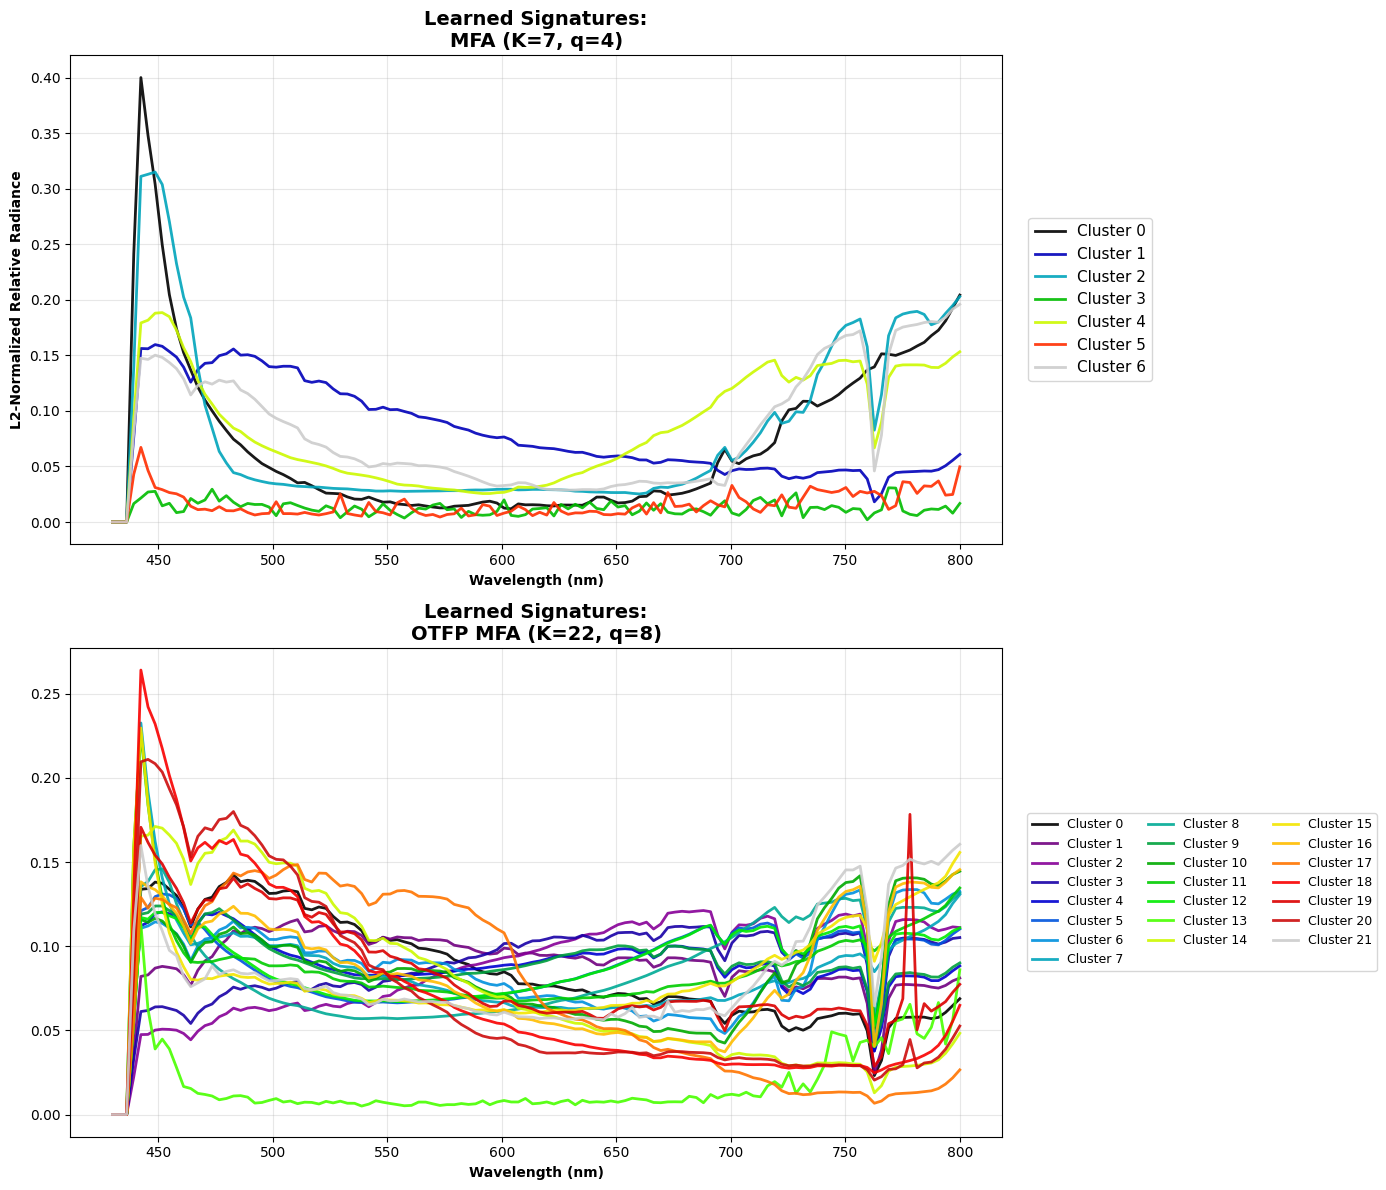

In [ ]:
# 1. Define wavelengths
wavelengths_nm = np.linspace(430, 800, 120) 

# 2. Pre-load all models (Reusing your robust logic)
model_states = [mfa_state, otfp_mfa_state]
loaded_models = []
for state in model_states:
    
    # Extract params
    K = state['hyperparameters']['n_components']
    q = state['hyperparameters']['n_factors']
    n_features = state['hyperparameters']['n_features']
    
    # Initialize Model
    mfa_model = MFA(n_components=K, n_channels=n_features, n_factors=q, device=device)
    mfa_model.load_state_dict(state['model_state_dict'])
    mfa_model.eval()
    
    # Deduce the preprocessing method from filename string
    model_type = "MFA"
    if state is otfp_mfa_state:
        model_type = "OTFP MFA"
    
    model_title = f"{model_type} (K={mfa_model.K}, q={mfa_model.q})"
    loaded_models.append({
        'model': mfa_model,
        'title': model_title
    })

# 3. Create the figure grid: 1 row, num_models columns
num_models = len(loaded_models)
fig, axes = plt.subplots(num_models, 1, figsize=(num_models * 7, 12))

# Ensure axes is an iterable array even if there is only 1 model
if num_models == 1:
    axes = [axes]

# 4. Iterate through loaded models and plot their signatures side-by-side
for j, model_info in enumerate(loaded_models):
    mfa_model = model_info['model']
    title = model_info['title']
    ax = axes[j]
    
    K = mfa_model.K
    
    # Extract means
    physical_means = mfa_model.mu.cpu().detach().numpy() 
    
    # Use nipy_spectral to match your image segmentation maps
    cmap = plt.get_cmap('nipy_spectral')
    
    for k in range(K):
        # Calculate dynamic color fraction to match the vmax/vmin scaling from earlier
        color_fraction = k / max(1, K - 1) 
        
        ax.plot(wavelengths_nm, physical_means[k], 
                label=f'Cluster {k}', 
                color=cmap(color_fraction), 
                linewidth=2.0, alpha=0.9)
        
    ax.set_title(f"Learned Signatures:\n{title}", fontweight='bold', fontsize=14)
    ax.set_xlabel("Wavelength (nm)", fontweight='bold')
    
    # Only label the Y-axis on the far left plot
    if j == 0:
        ax.set_ylabel("L2-Normalized Relative Radiance", fontweight='bold') 
    
    ax.grid(True, alpha=0.3)
    
    # Dynamically adjust legend columns based on K so it doesn't overflow
    if K > 20:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, ncol=3)
    elif K > 10:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, ncol=2)
    else:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11, ncol=1)

# Render the plot
plt.tight_layout()
plt.show()

### Mu with conficende-intervall

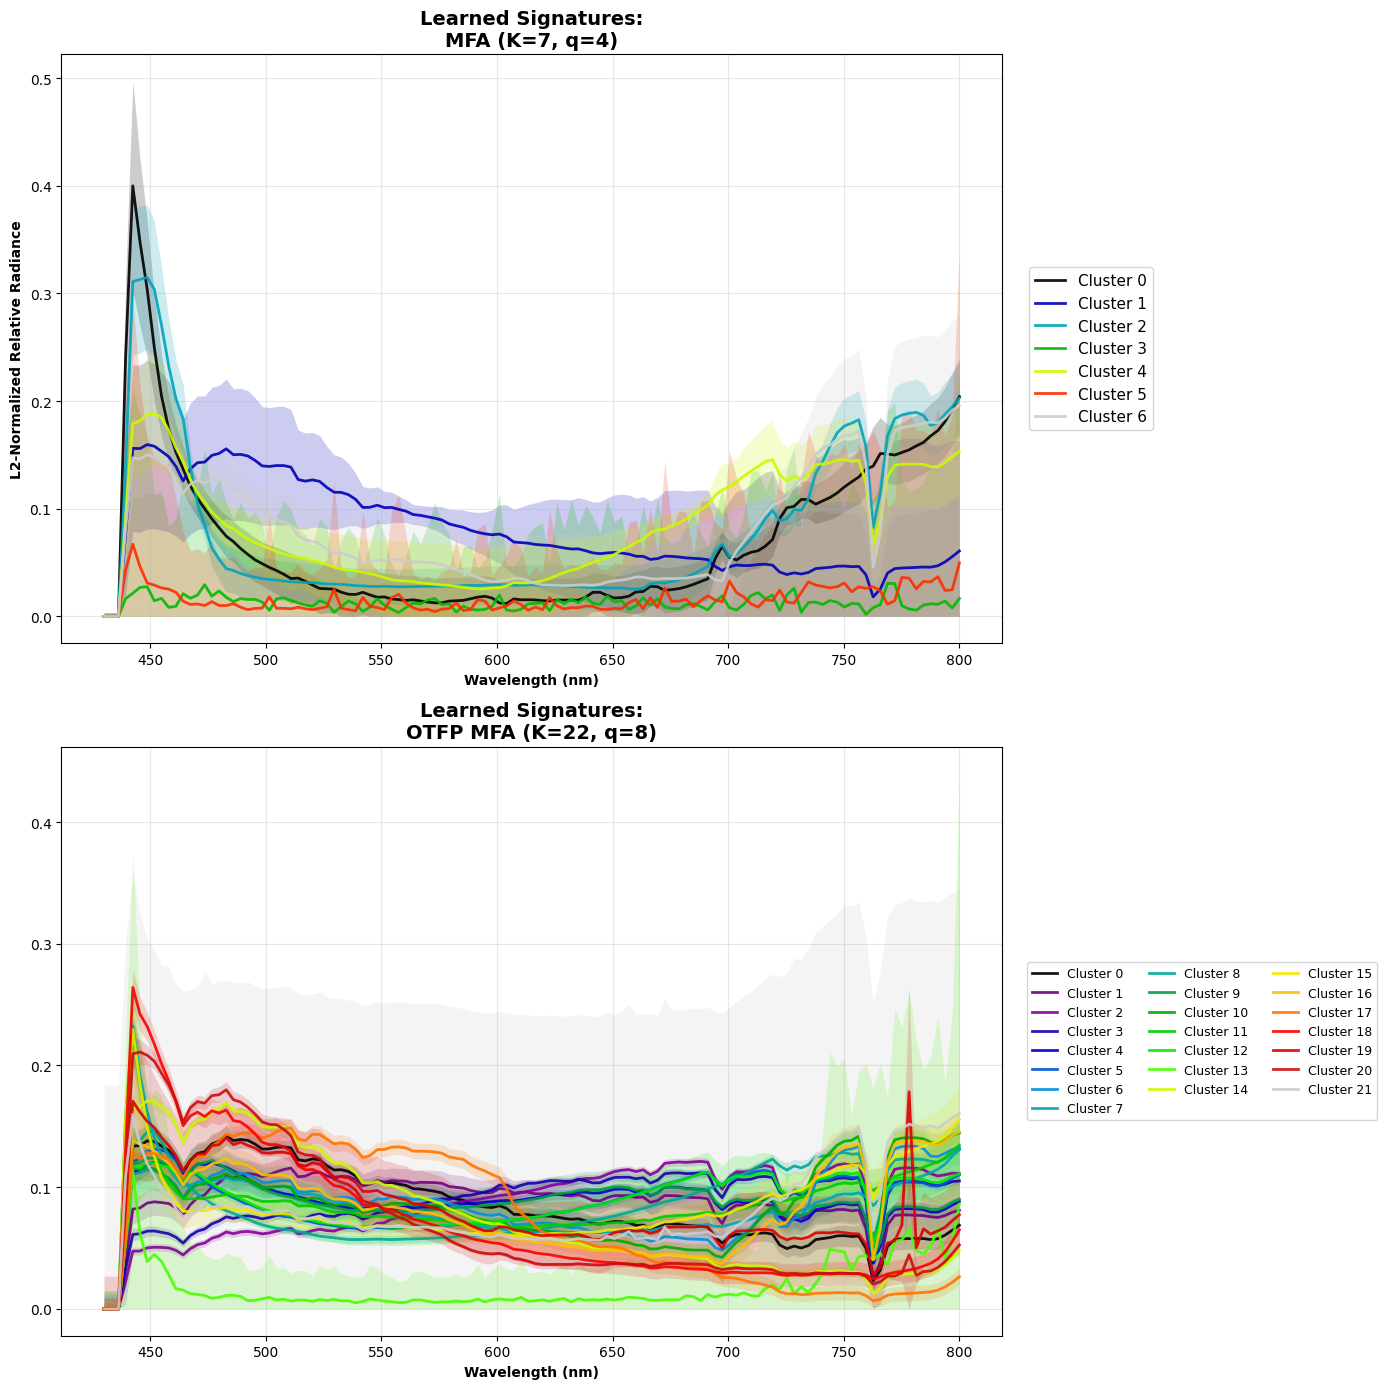

In [ ]:
# 1. Define wavelengths
wavelengths_nm = np.linspace(430, 800, 120) 

# 2. Pre-load all models (Reusing your robust logic)
model_states = [mfa_state, otfp_mfa_state]
loaded_models = []
for state in model_states:
    
    # Extract params
    K = state['hyperparameters']['n_components']
    q = state['hyperparameters']['n_factors']
    n_features = state['hyperparameters']['n_features']
    
    # Initialize Model
    mfa_model = MFA(n_components=K, n_channels=n_features, n_factors=q, device=device)
    mfa_model.load_state_dict(state['model_state_dict'])
    mfa_model.eval()
    
    # Deduce the preprocessing method from filename string
    model_type = "MFA"
    if state is otfp_mfa_state:
        model_type = "OTFP MFA"
    
    model_title = f"{model_type} (K={mfa_model.K}, q={mfa_model.q})"
    loaded_models.append({
        'model': mfa_model,
        'title': model_title
    })

# 3. Create the figure grid: 1 row, num_models columns
num_models = len(loaded_models)
fig, axes = plt.subplots(num_models, 1, figsize=(num_models * 7, 14))

# Ensure axes is an iterable array even if there is only 1 model
if num_models == 1:
    axes = [axes]

# 4. Iterate through loaded models and plot their signatures side-by-side
for j, model_info in enumerate(loaded_models):
    mfa_model = model_info['model']
    title = model_info['title']
    ax = axes[j]
    
    K = mfa_model.K
    
    # --- NEW: Extract means, factor loadings, and specific noise ---
    physical_means = mfa_model.mu.cpu().detach().numpy() 
    lambdas = mfa_model.Lambda.cpu().detach().numpy()          # Shape: (K, D, q)
    psi = torch.exp(mfa_model.log_psi).cpu().detach().numpy()  # Shape: (K, D)
    
    # Use nipy_spectral to match your image segmentation maps
    cmap = plt.get_cmap('nipy_spectral')
    
    for k in range(K):
        # Calculate dynamic color fraction to match the vmax/vmin scaling from earlier
        color_fraction = k / max(1, K - 1) 
        c = cmap(color_fraction)
        
        # --- NEW: Calculate Total Variance per band ---
        # The variance contributed by the manifold is the sum of squared loadings
        lambda_variance = np.sum(lambdas[k] ** 2, axis=1) # Shape: (D,)
        
        # Total variance = Manifold variance + independent sensor noise
        total_variance = lambda_variance + psi[k]
        
        # Get standard deviation for the confidence interval bounds
        std_dev = np.sqrt(total_variance)
        
        # Clamp the means to 0 (just in case the model's raw center dipped slightly negative)
        clamped_mean = np.maximum(physical_means[k], 0)
        
        # Clamp the lower bound to 0 to respect physical reality
        lower_bound = np.maximum(clamped_mean - std_dev, 0)
        upper_bound = clamped_mean + std_dev
        
        # Plot the clamped mean line
        ax.plot(wavelengths_nm, clamped_mean, 
                label=f'Cluster {k}', 
                color=c, 
                linewidth=2.0, alpha=0.9)
                
        # --- NEW: Plot the semi-transparent Bayesian variance envelope ---
        ax.fill_between(wavelengths_nm, lower_bound, upper_bound, 
                        color=c, alpha=0.2, linewidth=0)
        
    ax.set_title(f"Learned Signatures:\n{title}", fontweight='bold', fontsize=14)
    ax.set_xlabel("Wavelength (nm)", fontweight='bold')
    
    # Only label the Y-axis on the far left plot
    if j == 0:
        ax.set_ylabel("L2-Normalized Relative Radiance", fontweight='bold') 
    
    ax.grid(True, alpha=0.3)
    
    # Dynamically adjust legend columns based on K so it doesn't overflow
    if K > 20:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, ncol=3)
    elif K > 10:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, ncol=2)
    else:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11, ncol=1)

# Render the plot
plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
import pandas as pd

def print_otfp_noise_sampled(otfp_model, wavelengths_nm):
    """
    Prints the specific noise (Ψ) for every 10th band for all components 
    in the provided OTFP MFA model in a tabular format.
    """
    K = otfp_model.K
    
    # Extract the diagonal noise elements and convert from log-space
    # Shape: (K, D)
    psi = torch.exp(otfp_model.log_psi).cpu().detach().numpy()
    
    # Slice the data to get every 10th band
    sampled_wavelengths = wavelengths_nm[::10]
    sampled_psi = psi[:, ::10]
    
    # Format the wavelengths as strings for clean column headers
    col_names = [f"{w:.1f} nm" for w in sampled_wavelengths]
    row_names = [f"Cluster {k}" for k in range(K)]
    
    # Create a DataFrame for nice console formatting
    df_noise = pd.DataFrame(sampled_psi, index=row_names, columns=col_names)
    
    print(f"\n{'='*80}")
    print(f" COMPONENT-SPECIFIC NOISE (Ψ) - SAMPLED EVERY 10 BANDS | OTFP MFA (K={K})")
    print(f"{'='*80}\n")
    
    # Temporarily force pandas to print all columns on a single wide line
    with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.6f}'.format):
        print(df_noise)
        print("\n")

otfp_model_instance = loaded_models[1]['model']  
print_otfp_noise_sampled(otfp_model_instance, wavelengths_nm)


 COMPONENT-SPECIFIC NOISE (Ψ) - SAMPLED EVERY 10 BANDS | OTFP MFA (K=22)

            430.0 nm  461.1 nm  492.2 nm  523.3 nm  554.4 nm  585.5 nm  616.6 nm  647.6 nm  678.7 nm  709.8 nm  740.9 nm  772.0 nm
Cluster 0   0.000010  0.000020  0.000011  0.000010  0.000010  0.000010  0.000010  0.000010  0.000010  0.000017  0.000029  0.000025
Cluster 1   0.000095  0.000111  0.000104  0.000110  0.000106  0.000104  0.000108  0.000101  0.000103  0.000108  0.000102  0.000118
Cluster 2   0.000010  0.000010  0.000010  0.000010  0.000010  0.000010  0.000012  0.000010  0.000010  0.000010  0.000010  0.000010
Cluster 3   0.000010  0.000012  0.000012  0.000012  0.000012  0.000010  0.000010  0.000010  0.000010  0.000010  0.000010  0.000012
Cluster 4   0.000010  0.000025  0.000011  0.000010  0.000010  0.000010  0.000010  0.000010  0.000011  0.000016  0.000018  0.000012
Cluster 5   0.000010  0.000016  0.000010  0.000010  0.000010  0.000010  0.000010  0.000010  0.000010  0.000012  0.000011  0.000010
Cluster 

In [ ]:
import torch
import numpy as np
import pandas as pd

def print_otfp_loadings_sampled(otfp_model, wavelengths_nm):
    """
    Prints the factor loadings (Λ) for every 10th band for all components 
    in the provided OTFP MFA model in a tabular format.
    """
    K = otfp_model.K
    q = otfp_model.q
    
    # Extract the factor loadings tensor
    # Shape: (K, D, q)
    Lambda = otfp_model.Lambda.cpu().detach().numpy()
    
    # Slice the wavelengths to get every 10th band
    sampled_wavelengths = wavelengths_nm[::10]
    row_names = [f"{w:.1f} nm" for w in sampled_wavelengths]
    col_names = [f"Factor {i+1}" for i in range(q)]
    
    print(f"\n{'='*80}")
    print(f" COMPONENT-SPECIFIC LOADINGS (Λ) - SAMPLED EVERY 10 BANDS | OTFP MFA (K={K}, q={q})")
    print(f"{'='*80}")
    
    # Temporarily force pandas formatting for clean wide printing
    with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.6f}'.format):
        
        for k in range(K):
            print(f"\n--- CLUSTER {k} FACTOR LOADINGS ---")
            
            # Extract the 2D matrix for component k and slice every 10th band
            # Shape becomes: (D_sampled, q)
            sampled_lambda_k = Lambda[k, ::10, :]
            
            # Create a DataFrame for nice console formatting
            df_loadings = pd.DataFrame(sampled_lambda_k, index=row_names, columns=col_names)
            
            print(df_loadings)
        


otfp_model_instance = loaded_models[1]['model']  
print_otfp_loadings_sampled(otfp_model_instance, wavelengths_nm)


 COMPONENT-SPECIFIC LOADINGS (Λ) - SAMPLED EVERY 10 BANDS | OTFP MFA (K=22, q=8)

--- CLUSTER 0 FACTOR LOADINGS ---
          Factor 1  Factor 2  Factor 3  Factor 4  Factor 5  Factor 6  Factor 7  Factor 8
430.0 nm  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
461.1 nm -0.003173  0.005317  0.000034 -0.002599  0.004005  0.000703 -0.002772 -0.000709
492.2 nm -0.001884  0.002044  0.000677 -0.001952  0.001953  0.000146 -0.004102  0.000784
523.3 nm  0.000966  0.000182  0.000499 -0.002550 -0.000722  0.000489 -0.001968  0.001801
554.4 nm  0.001615 -0.000666  0.002252 -0.000913 -0.001758  0.000421  0.000173  0.001025
585.5 nm  0.002076 -0.001360  0.003128  0.000823 -0.001355 -0.000532  0.001440  0.000242
616.6 nm  0.002490 -0.001826  0.002064  0.001891 -0.001093 -0.001260  0.001396 -0.000363
647.6 nm  0.002865 -0.001819  0.000443  0.002386 -0.001185 -0.000896  0.000836 -0.000889
678.7 nm  0.003369 -0.001642 -0.001979  0.002873 -0.001451  0.000174 -0.000076 -0.